# HW3 part 2: Recursive Attitude Estimation and MEKF for Starling 6U
MEKF for the NASA Starling 6U CubeSat.

**MEKF with Gyro Bias** - augments the state with a 3 axis gyro bias estimate.
governing eqs:
- State: `x = [q; beta]`
- Prediction: `dq = expq(0.5*dt*(u - beta))`, `q_{k+1} = L(q_k)*dq`, `beta_{k+1} = beta_k`
- Jacobian: `A = [G(q+)' R(dq) G(q)  ,  -0.5*dt*G(q+)'*G(q) ;  0  ,  I]`
- Measurement C: `[dy/dphi, 0]` (same attitude jacobian, zero for bias columns)

The filter is tested in a slow uncontrolled tumble (few deg/s) with the Starling sensor suite developed in previous reports.

### Deliverables
1. Sample rate selection based on mission requirements
2. Filter errors vs. static (Wahba) estimates
3. Estimator consistency (covariance vs. actual errors)
4. Convergence behavior exploration


In [27]:
using LinearAlgebra
using Random
using Statistics
using PythonPlot

## 1. Quaternion utilities

Convention: `q = [s; v]` where `s` is the scalar element and `v` is the 3 vector element.

In [28]:
function hat(v)
    return [0 -v[3] v[2]; v[3] 0 -v[1]; -v[2] v[1] 0]
end

function unhat(S)
    return 0.5*[S[3,2]-S[2,3]; S[1,3]-S[3,1]; S[2,1]-S[1,2]]
end

const Hmat = [zeros(1,3); I(3)]

const Tmat = [1 zeros(1,3); zeros(3,1) -I(3)]

function Lmat(q)
    s = q[1]; v = q[2:4]
    return [s -v'; v s*I(3) + hat(v)]
end

function Rmat(q)
    s = q[1]; v = q[2:4]
    return [s -v'; v s*I(3) - hat(v)]
end

function Gmat(q)
    return Lmat(q) * Hmat
end

function Qmat(q)
    return Hmat' * (Rmat(q)' * Lmat(q)) * Hmat
end

function expq(phi)
    theta = norm(phi)
    return [cos(theta); phi * sinc(theta/pi)]
end

function logq(q)
    s = q[1]; v = q[2:4]; sn = norm(v)
    theta = atan(sn, s)
    return v / sinc(theta/pi)
end

function sample_noise(W)
    Lc = cholesky(Symmetric(Matrix(W))).L
    return Lc * randn(3)
end

println("Quaternion utilities loaded.")

Quaternion utilities loaded.


## 2. Spacecraft Dynamics (Torque Free Tumble)

Euler's equation w/o torque: `J * omega_dot = -(omega x (J*omega))`

Quaternion kinematics: `qdot = 0.5 * G(q) * omega`

Using Starling principal computed inertias (need to be updated)

In [29]:
#Starling 6U principal inertia

J = Diagonal([0.15214, 0.20986, 0.282]) #principal moments from J_body eigen-decomposition

function dynamics(x, J)
    q = x[1:4]; q = q/norm(q)
    omega = x[5:7]
    qdot = 0.5 * Gmat(q) * omega
    omega_dot = -J \ (hat(omega) * J * omega)
    return [qdot; omega_dot]
end

function rk4step(x, dt, J)
    f1 = dynamics(x, J)
    f2 = dynamics(x + 0.5*dt*f1, J)
    f3 = dynamics(x + 0.5*dt*f2, J)
    f4 = dynamics(x + dt*f3, J)
    xn = x + (dt/6.0)*(f1 + 2*f2 + 2*f3 + f4)
    xn[1:4] .= xn[1:4]/norm(xn[1:4])  #normalize quaternion again
    return xn
end

println("Dynamics loaded. J = diag($(diag(J)))")


Dynamics loaded. J = diag([0.15214, 0.20986, 0.282])


## 3. Sample rate selection

The Starling XACT system supports slew rates of 3-5 deg/s for the 6U bus.
For a slow uncontrolled tumble we use omega of 2-5 deg/s.
To track a 5 deg/s tumble, we would reasonably need 10 samples per revolution of the fastest dynamic mode. 
At 5 deg/s we get a 72 s per full rotation
The nutation period for our inertia is 10-15 s. Want >= 10 samples per nutation period so dt <= 1 s.
The gyro runs at 10 Hz so dt = 0.1 s, the baseline
Testing at dt = 0.5 s and dt = 1.0 s to show effect of sample rate 

In [30]:
#Simulation parameters
dt = 0.1       #10 Hz
nsteps = 6000  #600s
tf = nsteps * dt

println("Filter sample rate: $(1/dt) Hz, dt = $dt s")
println("Simulation duration: $tf s")

Filter sample rate: 10.0 Hz, dt = 0.1 s
Simulation duration: 600.0 s


## 4. Sensor models

In [31]:
# Sun sensor: 0.3 deg 1-sigma
sig_sun = 0.3 * (pi/180)
W_sun = sig_sun^2 * I(3)

# Magnetometer: 1.0 deg 1-sigma
sig_mag = 1.0 * (pi/180)
W_mag = sig_mag^2 * I(3)

# Gyro: ADIS16470-style model
# ARW = 0.34 deg/sqrt(hr)
ARW = 0.34 * (pi/180) / 60
sig_omega = ARW / sqrt(dt)
V_omega = sig_omega^2 * I(3)

# Gyro bias random walk
# 8 deg/hr bias stability converted to per-step random walk scale
sig_drift = 8.0 * (pi/180) / 3600
sig_beta = sig_drift * sqrt(dt) / sqrt(3600.0)
V_beta = sig_beta^2 * I(3)

# ±0.25% scale factor per axis, ±0.1° misalignment per axis pair (ADIS16470 spec)
function sample_M_gyro(; rng=Random.default_rng())
    α  = 0.1 * (pi/180)
    θ  = α    .* (2 .* rand(rng, 3) .- 1)    # θ[1]=xy  θ[2]=xz  θ[3]=yz
    δs = 0.0025 .* (2 .* rand(rng, 3) .- 1)  # scale errors per axis
    return [1+δs[1]      sin(θ[1])   sin(θ[2]);
            -sin(θ[1])   1+δs[2]     sin(θ[3]);
            -sin(θ[2])  -sin(θ[3])   1+δs[3] ]
end
M_gyro = sample_M_gyro()

# Combined measurement noise from sun and mag
m_vec = 2
W_meas = zeros(3*m_vec, 3*m_vec)
W_meas[1:3,1:3] = W_sun
W_meas[4:6,4:6] = W_mag

println("sig_omega = $(round(sig_omega*(180/pi)*3600, digits=2)) arcsec/s")
println("sig_beta  = $(round(sig_beta*(180/pi)*3600, digits=4)) arcsec/s/step")
println("M_gyro sampled.")

sig_omega = 64.51 arcsec/s
sig_beta  = 0.0422 arcsec/s/step
M_gyro sampled.


## 5. Generate truth trajectory and measurements

In [32]:
Random.seed!(42)

# random initial attitude
q0 = randn(4)
q0 = q0 / norm(q0)

# slow tumble: 3 deg/s
omega0 = 3.0 * (pi/180) * normalize(randn(3))

# random gyro bias
beta_true = 0.5 * (pi/180) * randn(3)

x0 = [q0; omega0]

# simulate truth trajectory
xtraj = zeros(7, nsteps)
xtraj[:,1] .= x0
for k = 1:(nsteps-1)
    xtraj[:,k+1] = rk4step(xtraj[:,k], dt, J)
end
println("Truth trajectory generated: $(nsteps) steps.")

# inertial reference vectors
r_sun_N = [1.0, 0.0, 0.0]
r_mag_N = normalize([0.3, 0.5, 0.8])
r_N = hcat(r_sun_N, r_mag_N)

# affine vector sensor model: y = M*yideal + b + w, then normalize
function affine_vector_meas(vtrue, M, b, W)
    return normalize(M * vtrue + b + cholesky(Symmetric(Matrix(W))).L * randn(3))
end

# Sun sensor: factory-calibrated, no residual misalignment spec → M = I, b = 0
M_sun = I(3)
b_sun = zeros(3)

# ±1° misalignment per axis pair (NSS_MAG orthogonality spec; no scale spec)
function sample_M_mag(; rng=Random.default_rng())
    α = 1.0 * (pi/180)
    θ = α .* (2 .* rand(rng, 3) .- 1)
    return [ 1.0         sin(θ[1])   sin(θ[2]);
            -sin(θ[1])   1.0         sin(θ[3]);
            -sin(θ[2])  -sin(θ[3])   1.0      ]
end
M_mag = sample_M_mag()
b_mag = [4.4e-3, 2.2e-3, 3.3e-3]

# generate noisy gyro measurements
# model: gyro_k = M_gyro * omega_true_k + beta_k + v_k
# bias evolves: beta_{k+1} = beta_k + eta_k
gyro_meas = zeros(3, nsteps)
beta_traj = zeros(3, nsteps)
beta_traj[:,1] .= beta_true

Lw = cholesky(Symmetric(Matrix(V_omega))).L
Lb = cholesky(Symmetric(Matrix(V_beta))).L

for k = 1:nsteps
    omega_true_k = xtraj[5:7,k]
    gyro_meas[:,k] = M_gyro * omega_true_k + beta_traj[:,k] + Lw * randn(3)

    if k < nsteps
        beta_traj[:,k+1] = beta_traj[:,k] + Lb * randn(3)
    end
end

# generate affine vector measurements from truth quaternion
m = size(r_N, 2)
ytraj = zeros(3*m, nsteps)

for k = 1:nsteps
    Qk = Qmat(xtraj[1:4,k])

    y_sun_true = Qk' * r_N[:,1]
    y_mag_true = Qk' * r_N[:,2]

    ytraj[1:3, k] = affine_vector_meas(y_sun_true, M_sun, b_sun, W_sun)
    ytraj[4:6, k] = affine_vector_meas(y_mag_true, M_mag, b_mag, W_mag)
end

println("Measurements generated: $(nsteps) gyro + $(nsteps) vector measurement sets.")

Truth trajectory generated: 6000 steps.
Measurements generated: 6000 gyro + 6000 vector measurement sets.


In [33]:
#simulate truth trajectory
xtraj = zeros(7, nsteps)
xtraj[:,1] .= x0
for k = 1:(nsteps-1)
    xtraj[:,k+1] = rk4step(xtraj[:,k], dt, J)
end
println("Truth trajectory generated: $(nsteps) steps.")

Truth trajectory generated: 6000 steps.


## 6. Simple MEKF on attitude (not using this)


**Prediction:**
- `dq_k = expq(0.5 * dt * omega_k)` where `omega_k` comes from gyro
- `q_{k+1|k} = L(q_{k|k}) * dq_k`
- `A_k = G(q_{k+1|k})' * R(dq_k) * G(q_{k|k})`
- `P_{k+1|k} = A_k * P_{k|k} * A_k' + V`

**Measurement model:**
- `y = Q(q)' * r_N` body frame obsv of inertial vector
- `C = H' * [L(q)'*L(H*r) + R(q)*R(H*r)*T] * G(q)` jacobian wrt. phi

**Update:**
- `phi = K * z`
- `delta_q = [sqrt(1 - phi'*phi); phi]`
- `q_{k+1|k+1} = L(q_{k+1|k}) * delta_q`
- `P_{k+1|k+1} = (I - K*C)*P_{k+1|k}*(I - K*C)' + K*W*K'`  joseph form

In [34]:
function attitude_error_deg(qhat, qtrue)
    dq = Lmat(qhat)' * qtrue
    if dq[1] < 0
        dq = -dq
    end
    return norm(2 * logq(dq)) * (180/pi)
end

#simple mekf prediction
#q_{k+1|k} = L(q_k) * expq(0.5*dt*omega)
function simple_predict_state(q, omega, dt)
    dq = expq(0.5 * dt * omega)
    return Lmat(q) * dq
end

#A_k = G(q_{k+1|k})' * R(dq) * G(q_k)
function simple_predict_jacobian(q, omega, dt)
    dq = expq(0.5 * dt * omega)
    qn = Lmat(q) * dq
    return Gmat(qn)' * Rmat(dq) * Gmat(q)
end


#y = Q(q)' * r_N  vector over all ref
function meas_predict(q, r_N)
    Qk = Qmat(q)
    y = Qk' * r_N
    return y[:]   #stack to vector
end

#C_k = H' * [L(q)'*L(H*r) + R(q)*R(H*r)*T] * G(q)
function meas_jacobian_simple(q, r_N)
    m = size(r_N, 2)
    C = zeros(3*m, 3)
    for k = 1:m
        rk = r_N[:,k]
        C[((k-1)*3).+(1:3), :] .= Hmat' * (Lmat(q)' * Lmat(Hmat*rk) + Rmat(q) * Rmat(Hmat*rk) * Tmat) * Gmat(q)
    end
    return C
end

meas_jacobian_simple (generic function with 1 method)

In [35]:
#process noise for simple MEKF, attitude 
V_simple = 0.01 * I(3)
qfilt_simple = zeros(4, nsteps)
qfilt_simple[:,1] = q0 + 0.1*randn(4)
qfilt_simple[:,1] = qfilt_simple[:,1] / norm(qfilt_simple[:,1])

P_simple = zeros(3, 3, nsteps)
P_simple[:,:,1] .= 0.5 * I(3)

for k = 1:(nsteps-1)
    #Prediction 
    qpred = simple_predict_state(qfilt_simple[:,k], gyro_meas[:,k], dt)
    A = simple_predict_jacobian(qfilt_simple[:,k], gyro_meas[:,k], dt)
    Ppred = A * P_simple[:,:,k] * A' + V_simple

    #Innovation
    z = ytraj[:,k+1] - meas_predict(qpred, r_N)
    C = meas_jacobian_simple(qpred, r_N)
    S = C * Ppred * C' + W_meas

    #Kalman Gain
    K = Ppred * C' / S

    #Update
    phi = K * z
    phi_norm_sq = dot(phi, phi)
    delta_q = [sqrt(max(0.0, 1.0 - phi_norm_sq)); phi]
    delta_q = delta_q / norm(delta_q)
    qfilt_simple[:,k+1] = Lmat(qpred) * delta_q
    qfilt_simple[:,k+1] ./= norm(qfilt_simple[:,k+1])

    #Covariance update (Joseph form)
    IKC = I(3) - K*C
    P_simple[:,:,k+1] = IKC * Ppred * IKC' + K * W_meas * K'
end

println("Simple MEKF complete.")

Simple MEKF complete.


## 7. MEKF with Gyro Bias Estimation

**State:** `x = [q; beta]` where beta is the 3 axis gyro bias.

**Error state:** 6-dimensional `[phi; delta_beta]`

**Gyro model:**
- `u_k = omega_true + beta_k + v_omega`
- `beta_{k+1} = beta_k + v_beta`

**Prediction:**
- `dq_k = expq(0.5 * dt * (u_k - beta_k))`  #corrected gyro
- `q_{k+1|k} = L(q_k) * dq_k`
- `beta_{k+1|k} = beta_k`

**Jacobian A:**

A = [d_phi_{k+1}/d_phi_k, d_phi_{k+1}/d_beta_k]; [0, I]

- `d_phi_{k+1}/d_phi_k = G(q_{k+1})' * R(dq) * G(q_k)`
- `d_phi_{k+1}/d_beta_k = -0.5 * dt * G(q_{k+1})' * G(q_k)`

**Measurement C:**
- `C = [dy/dphi, 0]`  (same jacobian, zero columns for bias cause measurement doesnt depend on beta)

In [36]:
#bias mekf prediction
function bias_predict_state(x, u, dt)
    q = x[1:4]
    beta = x[5:7]
    omega_corr = u - beta            #w corrected
    dq = expq(0.5 * dt * omega_corr)
    qn = Lmat(q) * dq
    return [qn; beta]
end

#bias mekf jacobian
function bias_predict_jacobian(x, u, dt)
    q = x[1:4]
    beta = x[5:7]
    omega_corr = u - beta
    dq = expq(0.5 * dt * omega_corr)
    qn = Lmat(q) * dq

    #upper left: d_phi_{k+1} / d_phi_k
    A11 = Gmat(qn)' * Rmat(dq) * Gmat(q)

    #upper right: d_phi_{k+1} / d_beta_k = -0.5*dt * G(q+)' * G(q)
    A12 = -0.5 * dt * Gmat(qn)' * Gmat(q)

    #lower: d_beta_{k+1}/d_phi_k = 0,  d_beta_{k+1}/d_beta_k = I
    A = [A11  A12;
         zeros(3,3) I(3)]
    return A
end

function meas_jacobian_bias(q, r_N)
    m = size(r_N, 2)
    C = zeros(3*m, 6)
    for k = 1:m
        rk = r_N[:,k]
        C[((k-1)*3).+(1:3), 1:3] .= Hmat' * (Lmat(q)' * Lmat(Hmat*rk) + Rmat(q) * Rmat(Hmat*rk) * Tmat) * Gmat(q)
    end

    return C
end

meas_jacobian_bias (generic function with 1 method)

In [37]:
#process noise
V_bias_mekf = Diagonal(vcat(fill(0.01, 3), fill(sig_beta^2, 3)))

#filter initialization
xfilt_bias = zeros(7, nsteps)
xfilt_bias[1:4,1] = q0 + 0.1*randn(4)
xfilt_bias[1:4,1] = xfilt_bias[1:4,1] / norm(xfilt_bias[1:4,1])
xfilt_bias[5:7,1] .= 0.0 #0 starting

P_bias = zeros(6, 6, nsteps)
P_bias[:,:,1] .= Diagonal(vcat(fill(0.5, 3), fill(1.0, 3)))

for k = 1:(nsteps-1)
    #prediction
    xpred = bias_predict_state(xfilt_bias[:,k], gyro_meas[:,k], dt)
    A = bias_predict_jacobian(xfilt_bias[:,k], gyro_meas[:,k], dt)
    Ppred = A * P_bias[:,:,k] * A' + V_bias_mekf

    #innovation
    z = ytraj[:,k+1] - meas_predict(xpred[1:4], r_N)
    C = meas_jacobian_bias(xpred[1:4], r_N)
    S = C * Ppred * C' + W_meas

    #kalman gain
    K = Ppred * C' / S

    #update
    dx = K * z
    phi = dx[1:3]          #attitude correction
    dbeta = dx[4:6]        #bias correction

    #quaternion multiplicative update
    phi_norm_sq = dot(phi, phi)
    delta_q = [sqrt(max(0.0, 1.0 - phi_norm_sq)); phi]
    delta_q = delta_q / norm(delta_q)
    xfilt_bias[1:4,k+1] = Lmat(xpred[1:4]) * delta_q
    xfilt_bias[1:4,k+1] ./= norm(xfilt_bias[1:4,k+1])

    #bias additive update
    xfilt_bias[5:7,k+1] = xpred[5:7] + dbeta

    #cov update
    IKC = I(6) - K*C
    P_bias[:,:,k+1] = IKC * Ppred * IKC' + K * W_meas * K'
end

println("Bias MEKF complete.")

Bias MEKF complete.


## 8. Quaternion Tracking

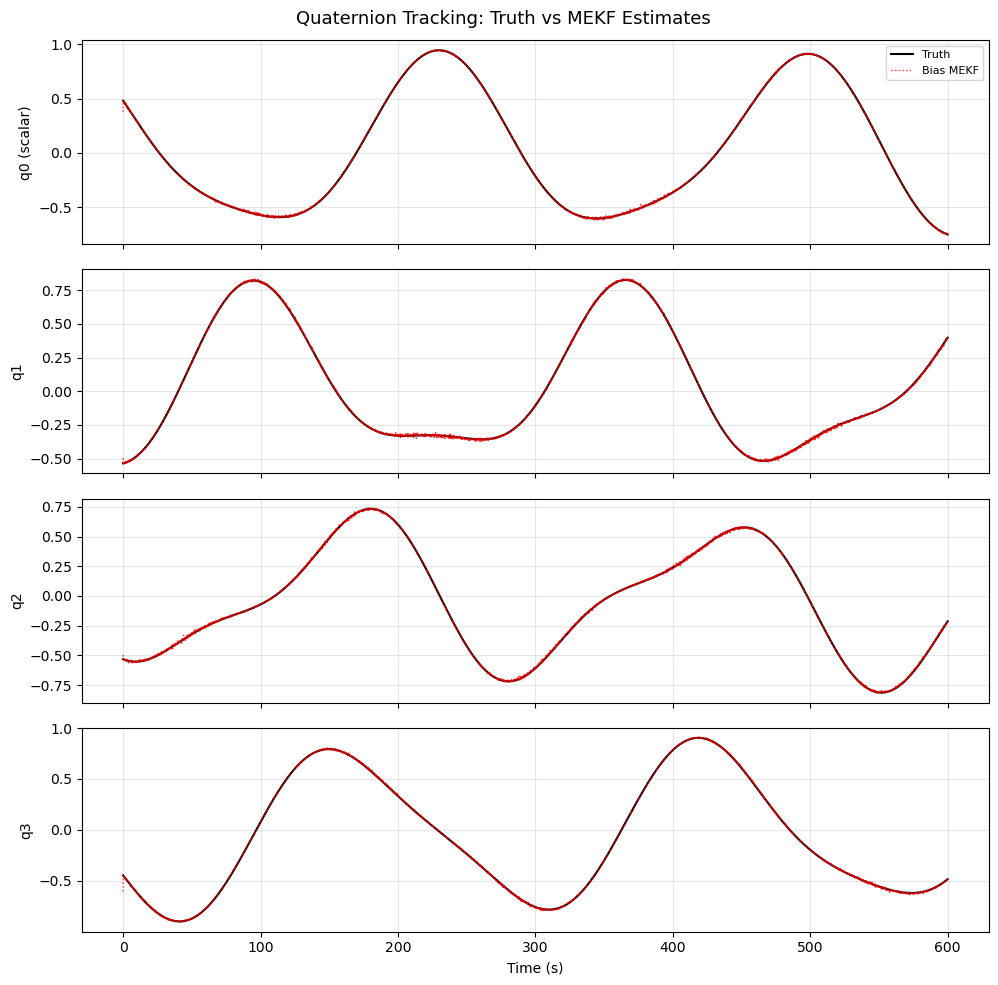

In [38]:
tvec = (0:nsteps-1) .* dt

fig, axes = subplots(4, 1, figsize=(10, 10), sharex=true)
qlabels = ["q0 (scalar)", "q1", "q2", "q3"]
for i = 1:4
    axes[i-1].plot(tvec, xtraj[i,:], "k-", linewidth=1.5, label="Truth")
    axes[i-1].plot(tvec, xfilt_bias[i,:], "r:", linewidth=1.0, alpha=0.8, label="Bias MEKF")
    axes[i-1].set_ylabel(qlabels[i])
    axes[i-1].grid(true, alpha=0.3)
    if i == 1; axes[i-1].legend(fontsize=8); end
end
axes[3].set_xlabel("Time (s)")
fig.suptitle("Quaternion Tracking: Truth vs MEKF Estimates", fontsize=13)
tight_layout()
display(fig)

## 9. Gyro Bias Estimation

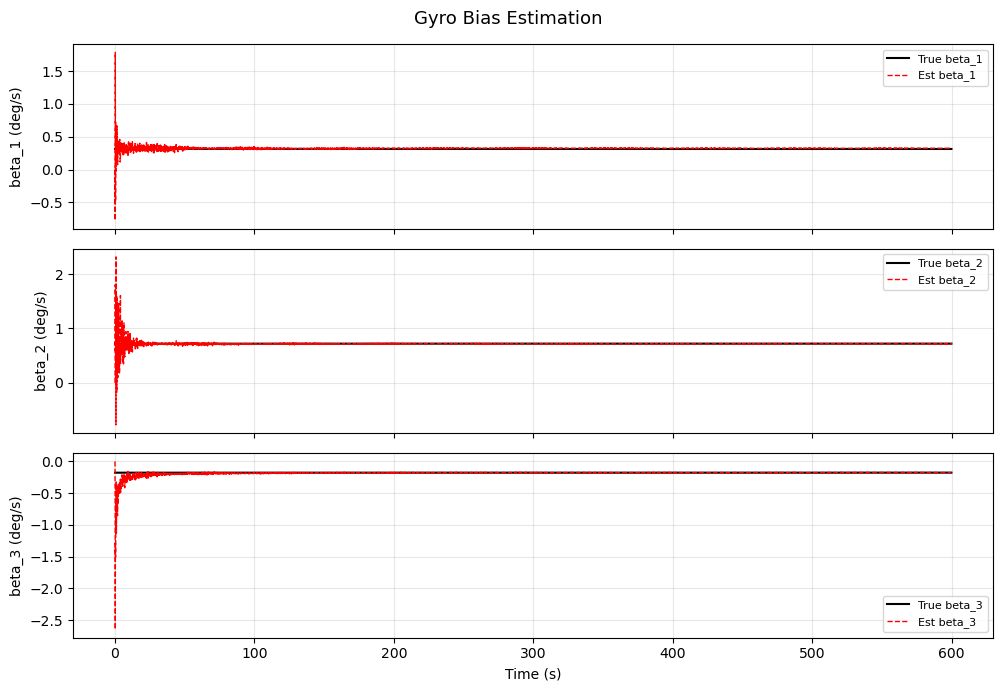

In [39]:
fig2, axes2 = subplots(3, 1, figsize=(10, 7), sharex=true)
for i = 1:3
    axes2[i-1].plot(tvec, beta_traj[i,:] * (180/pi), "k-", linewidth=1.5, label="True beta_$i")
    axes2[i-1].plot(tvec, xfilt_bias[4+i,:] * (180/pi), "r--", linewidth=1.0, label="Est beta_$i")
    axes2[i-1].set_ylabel("beta_$i (deg/s)")
    axes2[i-1].grid(true, alpha=0.3)
    axes2[i-1].legend(fontsize=8)
end
axes2[2].set_xlabel("Time (s)")
fig2.suptitle("Gyro Bias Estimation", fontsize=13)
tight_layout()
display(fig2)


## 10. Attitude Error Comparison for Filter vs Static Wahba 

In [40]:
#Wahba SVD solver
function wahba_svd(r_B_list, r_N_list, weights)
    B = zeros(3,3)
    for k in eachindex(r_B_list)
        B += weights[k] * r_B_list[k] * r_N_list[k]'
    end
    F = svd(B)
    return F.V * Diagonal([1.0, 1.0, det(F.V)*det(F.U)]) * F.U'
end

w_sun = (1/sig_sun^2) / (1/sig_sun^2 + 1/sig_mag^2)
w_mag = 1 - w_sun

err_bias  = zeros(nsteps)
err_wahba = zeros(nsteps)

for k = 1:nsteps
    # bias MEKF error
    err_bias[k] = attitude_error_deg(xfilt_bias[1:4,k], xtraj[1:4,k])

    # static Wahba error
    r_B_sun = ytraj[1:3, k]
    r_B_mag = ytraj[4:6, k]

    try
        Q_w = wahba_svd([r_B_sun, r_B_mag], [r_sun_N, r_mag_N], [w_sun, w_mag])

        # convert rotation matrix error to angle
        Q_true = Qmat(xtraj[1:4,k])
        dQ = Q_w' * Q_true
        theta = acos(clamp((tr(dQ) - 1)/2, -1.0, 1.0))
        err_wahba[k] = theta * (180/pi)
    catch
        err_wahba[k] = NaN
    end
end

println("Steady-state errors (last 50%):")
idx_ss = div(nsteps,2):nsteps
println("  Bias MEKF:      mean=$(round(mean(err_bias[idx_ss]), digits=4)) deg, RMS=$(round(sqrt(mean(err_bias[idx_ss].^2)), digits=4)) deg")
println("  Wahba (static): mean=$(round(mean(filter(!isnan, err_wahba[idx_ss])), digits=4)) deg, RMS=$(round(sqrt(mean(filter(!isnan, err_wahba[idx_ss]).^2)), digits=4)) deg")

Steady-state errors (last 50%):
  Bias MEKF:      mean=1.0495 deg, RMS=1.2265 deg
  Wahba (static): mean=1.0551 deg, RMS=1.2336 deg


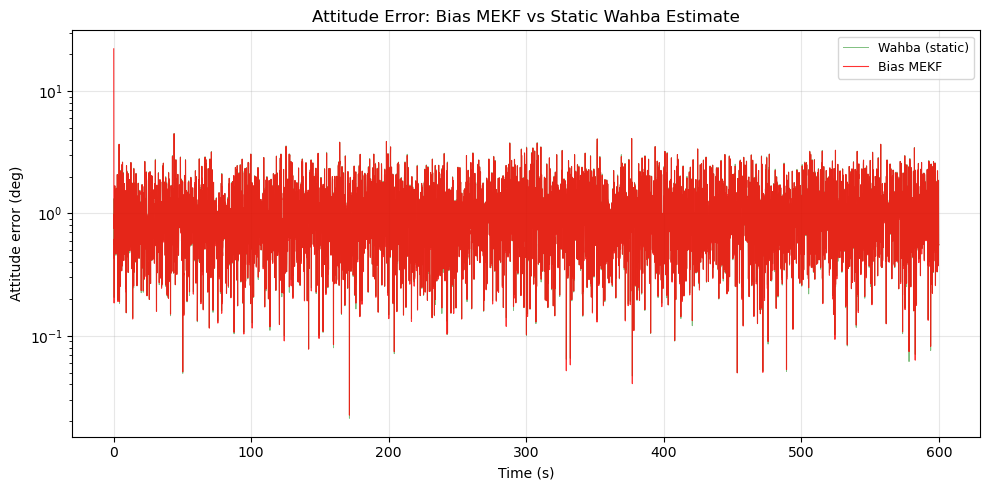

In [41]:
fig3, (ax3_bias, ax3_wahba) = subplots(2, 1, figsize=(10, 7), sharex=true, sharey=true)

combined_err = vcat(
    filter(x -> isfinite(x) && x > 0, err_bias),
    filter(x -> isfinite(x) && x > 0, err_wahba),
)
ylo, yhi = minimum(combined_err), maximum(combined_err)
ypad = 10.0^(0.05 * (log10(yhi) - log10(ylo)))
ylims = (ylo / ypad, yhi * ypad)

ax3_bias.plot(tvec, err_bias, "r-", linewidth=0.8, alpha=0.8, label="Bias MEKF")
ax3_bias.set_ylabel("Attitude error (deg)")
ax3_bias.set_title("Attitude Error: Bias MEKF vs Static Wahba Estimate")
ax3_bias.legend(fontsize=9)
ax3_bias.grid(true, alpha=0.3)
ax3_bias.set_yscale("log")
ax3_bias.set_ylim(ylims...)

ax3_wahba.plot(tvec, err_wahba, "g-", linewidth=0.8, alpha=0.9, label="Wahba (static)")
ax3_wahba.set_xlabel("Time (s)")
ax3_wahba.set_ylabel("Attitude error (deg)")
ax3_wahba.legend(fontsize=9)
ax3_wahba.grid(true, alpha=0.3)
ax3_wahba.set_yscale("log")
ax3_wahba.set_ylim(ylims...)

tight_layout()
display(fig3)

## 11. Estimator Consistency Check

Our filter covariance is consistent with the actual errors. Plotted is the actual attitude error alongside the +/- 1-sigma and +/- 3-sigma bounds from the filter covariance P.

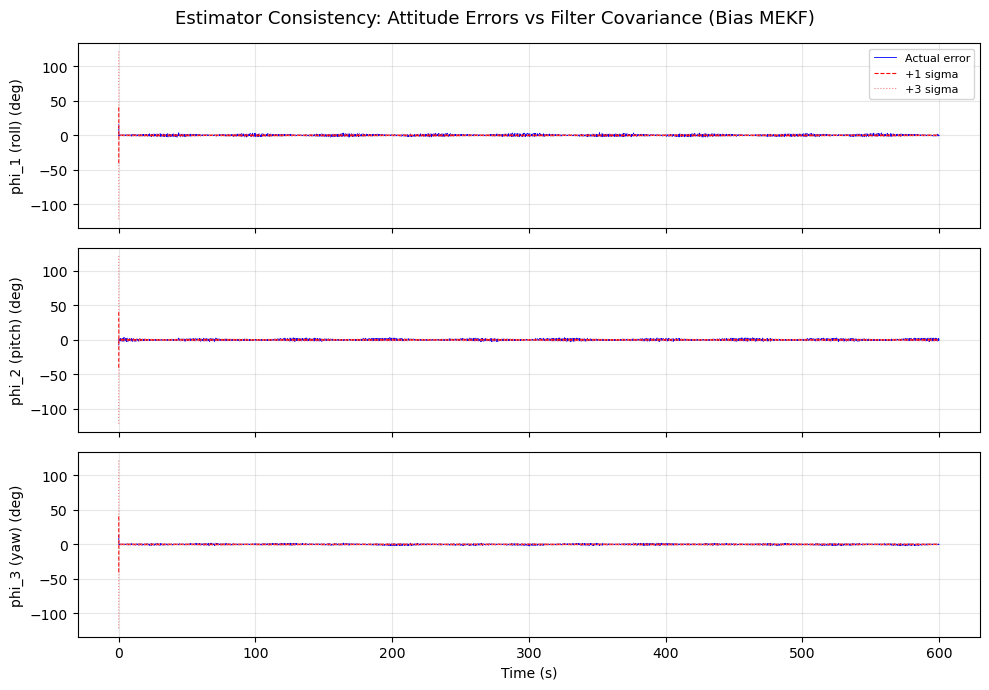

In [42]:
#compute per axis attitude errors for bias 
# ---------- Estimator consistency check: attitude ----------
phi_err = zeros(3, nsteps)
sig_P   = zeros(3, nsteps)

for k = 1:nsteps
    dq = Lmat(xfilt_bias[1:4,k])' * xtraj[1:4,k]
    if dq[1] < 0
        dq = -dq
    end
    phi_err[:,k] = 2 * logq(dq) * (180/pi)

    for i = 1:3
        sig_P[i,k] = sqrt(max(0.0, P_bias[i,i,k])) * (180/pi)
    end
end

fig4, axes4 = subplots(3, 1, figsize=(10, 7), sharex=true)
labels = ["phi_1 (roll)", "phi_2 (pitch)", "phi_3 (yaw)"]

for i = 1:3
    axes4[i-1].plot(tvec, phi_err[i,:], "b-", linewidth=0.6, label="Actual error")
    axes4[i-1].plot(tvec,  sig_P[i,:], "r--", linewidth=0.8, label="+1 sigma")
    axes4[i-1].plot(tvec, -sig_P[i,:], "r--", linewidth=0.8)
    axes4[i-1].plot(tvec,  3*sig_P[i,:], color="lightcoral", linestyle=":", linewidth=0.8, label="+3 sigma")
    axes4[i-1].plot(tvec, -3*sig_P[i,:], color="lightcoral", linestyle=":", linewidth=0.8)
    axes4[i-1].set_ylabel("$(labels[i]) (deg)")
    axes4[i-1].grid(true, alpha=0.3)
    if i == 1
        axes4[i-1].legend(fontsize=8)
    end
end

axes4[2].set_xlabel("Time (s)")
fig4.suptitle("Estimator Consistency: Attitude Errors vs Filter Covariance (Bias MEKF)", fontsize=13)
tight_layout()
display(fig4)

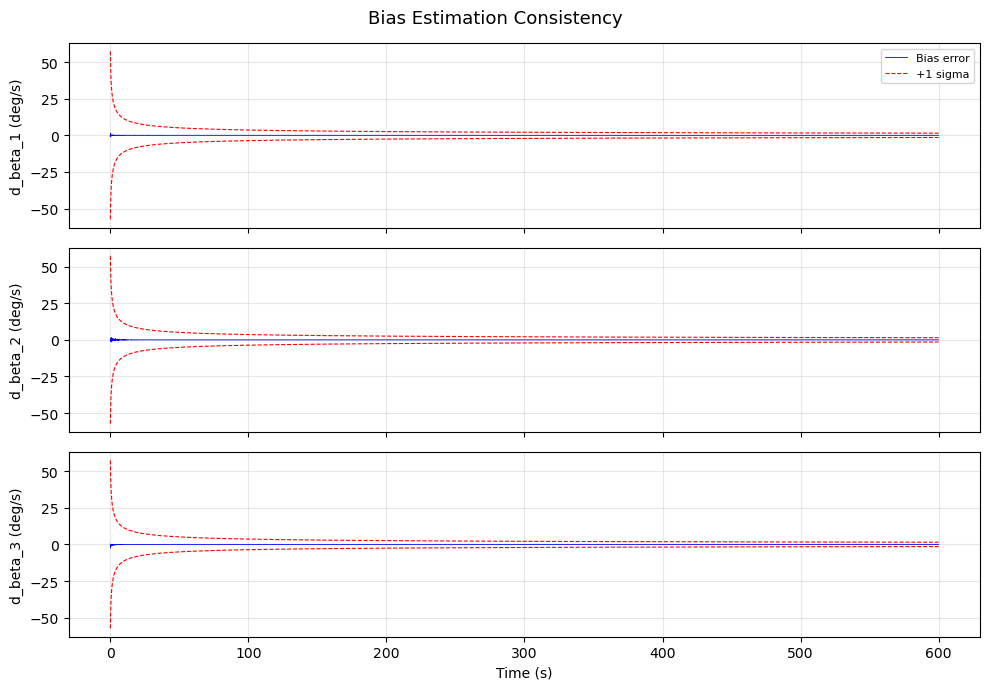

In [43]:
fig5, axes5 = subplots(3, 1, figsize=(10, 7), sharex=true)

for i = 1:3
    beta_err = (xfilt_bias[4+i,:] - beta_traj[i,:]) * (180/pi)
    sig_b = sqrt.(max.(0.0, P_bias[3+i, 3+i, :])) * (180/pi)

    axes5[i-1].plot(tvec, beta_err, "b-", linewidth=0.6, label="Bias error")
    axes5[i-1].plot(tvec,  sig_b, "r--", linewidth=0.8, label="+1 sigma")
    axes5[i-1].plot(tvec, -sig_b, "r--", linewidth=0.8)
    axes5[i-1].set_ylabel("d_beta_$i (deg/s)")
    axes5[i-1].grid(true, alpha=0.3)

    if i == 1
        axes5[i-1].legend(fontsize=8)
    end
end

axes5[2].set_xlabel("Time (s)")
fig5.suptitle("Bias Estimation Consistency", fontsize=13)
tight_layout()
display(fig5)


## 12. Convergence behavior for diff states

In [44]:
#for easier delivarable 4, this thing takaes in diff initial att errors and covs
function run_bias_mekf(q0_filt, beta0_filt, P0, gyro_data, y_data, r_N_ref, dt, ns, V_proc, W_obs)
    xf = zeros(7, ns)
    xf[1:4,1] = q0_filt / norm(q0_filt)
    xf[5:7,1] = beta0_filt

    Pf = zeros(6, 6, ns)
    Pf[:,:,1] .= P0

    err_att = zeros(ns)

    # error at initial time before any update
    err_att[1] = attitude_error_deg(xf[1:4,1], xtraj[1:4,1])

    for k = 1:(ns-1)
        xpred = bias_predict_state(xf[:,k], gyro_data[:,k], dt)
        A = bias_predict_jacobian(xf[:,k], gyro_data[:,k], dt)
        Ppred = A * Pf[:,:,k] * A' + V_proc

        z = y_data[:,k+1] - meas_predict(xpred[1:4], r_N_ref)
        Ck = meas_jacobian_bias(xpred[1:4], r_N_ref)
        Sk = Ck * Ppred * Ck' + W_obs
        Kk = Ppred * Ck' / Sk

        dx = Kk * z
        phi = dx[1:3]
        dbeta = dx[4:6]

        phi_norm_sq = dot(phi, phi)
        dq = [sqrt(max(0.0, 1.0 - phi_norm_sq)); phi]
        dq = dq / norm(dq)

        xf[1:4,k+1] = Lmat(xpred[1:4]) * dq
        xf[1:4,k+1] ./= norm(xf[1:4,k+1])
        xf[5:7,k+1] = xpred[5:7] + dbeta

        IKC = I(6) - Kk*Ck
        Pf[:,:,k+1] = IKC * Ppred * IKC' + Kk * W_obs * Kk'

        err_att[k+1] = attitude_error_deg(xf[1:4,k+1], xtraj[1:4,k+1])
    end

    return err_att, xf, Pf
end

println("run_bias_mekf updated.")

run_bias_mekf updated.


Requested initial error = 5.0 deg, actual injected = 5.0 deg
Requested initial error = 20.0 deg, actual injected = 20.0 deg
Requested initial error = 45.0 deg, actual injected = 45.0 deg
Requested initial error = 90.0 deg, actual injected = 90.0 deg
Requested initial error = 150.0 deg, actual injected = 150.0 deg


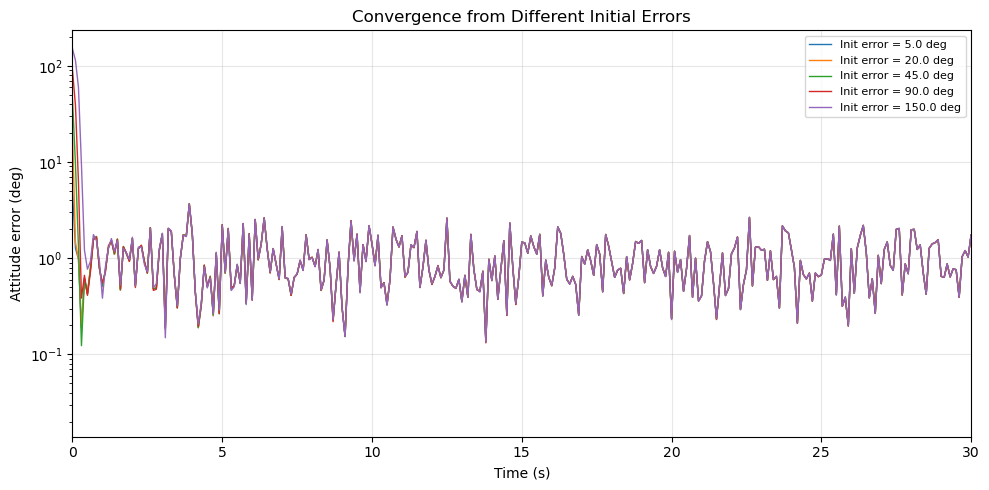

Convergence plot generated.


In [45]:
Random.seed!(123)

init_errors_deg = [5.0, 20.0, 45.0, 90.0, 150.0]
P0_base = Diagonal(vcat(fill(1.0, 3), fill(1.0, 3)))

fig6, ax6 = subplots(figsize=(10, 5))

for err_deg in init_errors_deg
    ax = normalize(randn(3))
    phi_init = err_deg * (pi/180) * ax

    q0_off = Lmat(xtraj[1:4,1]) * expq(0.5 * phi_init)
    q0_off = q0_off / norm(q0_off)

    dq0 = Lmat(q0_off)' * xtraj[1:4,1]
    if dq0[1] < 0
        dq0 = -dq0
    end
    err0_check = norm(2 * logq(dq0)) * (180/pi)
    println("Requested initial error = $err_deg deg, actual injected = $(round(err0_check, digits=3)) deg")

    err_traj, _, _ = run_bias_mekf(q0_off, zeros(3), P0_base,
                                   gyro_meas, ytraj, r_N, dt, nsteps,
                                   V_bias_mekf, W_meas)

    ax6.plot(tvec, err_traj, linewidth=1.0, label="Init error = $(err_deg) deg")
end

ax6.set_xlabel("Time (s)")
ax6.set_ylabel("Attitude error (deg)")
ax6.set_title("Convergence from Different Initial Errors")
ax6.set_yscale("log")
ax6.set_xlim(0, 30)   # zoom into the transient; remove this if you want the full 600 s view
ax6.grid(true, alpha=0.3)
ax6.legend(fontsize=8)
tight_layout()
display(fig6)
println("Convergence plot generated.")

## 13. Sample Rate Sensitivity

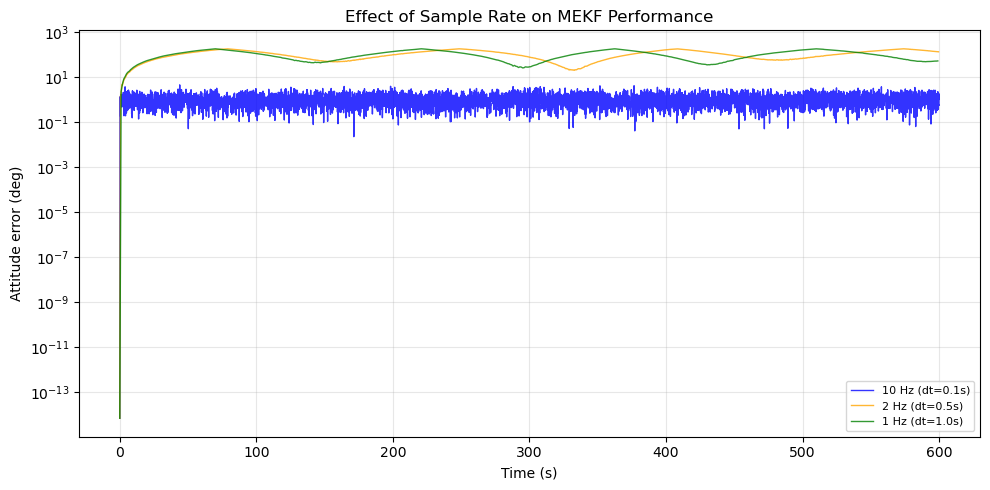

In [46]:
#comparing diff performance for diff sampleing rates
fig7, ax7 = subplots(figsize=(10, 5))

q_proc_base = 0.01

for (ds, clr, lbl) in [(1, "blue", "10 Hz (dt=0.1s)"),
                        (5, "orange", "2 Hz (dt=0.5s)"),
                        (10, "green", "1 Hz (dt=1.0s)")]

    dt_ds = dt * ds
    ns_ds = div(nsteps - 1, ds) + 1

    gyro_ds = gyro_meas[:, 1:ds:nsteps]
    ytraj_ds = ytraj[:, 1:ds:nsteps]

    V_ds = Diagonal(vcat(fill(q_proc_base * ds, 3), fill(sig_beta^2 * ds, 3)))

    err_ds, _, _ = run_bias_mekf(xtraj[1:4,1], zeros(3), P0_base,
                                 gyro_ds, ytraj_ds, r_N, dt_ds, ns_ds,
                                 V_ds, W_meas)

    tvec_ds = (0:ns_ds-1) .* dt_ds
    ax7.plot(tvec_ds, err_ds, color=clr, linewidth=1.0, alpha=0.8, label=lbl)
end

ax7.set_xlabel("Time (s)")
ax7.set_ylabel("Attitude error (deg)")
ax7.set_title("Effect of Sample Rate on MEKF Performance")
ax7.set_yscale("log")
ax7.grid(true, alpha=0.3)
ax7.legend(fontsize=8)
tight_layout()
display(fig7)

## 14. Monte Carlo Analysis (Multiple Random Initial Conditions)

In [47]:
N_mc = 50
ss_errors_mc = zeros(N_mc)
conv_times_mc = fill(NaN, N_mc)

Random.seed!(999)

n_hold = 50
conv_thresh_deg = 1.5
P0_base = Diagonal(vcat(fill(1.0, 3), fill(1.0, 3)))

for trial = 1:N_mc
    # Sample fresh misalignment matrices for this trial
    # Sun sensor: M = I (factory-calibrated, no residual spec), no per-trial resampling
    M_gyro_t = sample_M_gyro()
    M_sun_t  = I(3)
    M_mag_t  = sample_M_mag()

    # Regenerate gyro measurements with this trial's M_gyro (beta_traj fixed from cell 11)
    gyro_t = zeros(3, nsteps)
    for k = 1:nsteps
        gyro_t[:, k] = M_gyro_t * xtraj[5:7, k] + beta_traj[:, k] + Lw * randn(3)
    end

    # Regenerate vector measurements with this trial's M_sun, M_mag
    ytraj_t = zeros(3*m, nsteps)
    for k = 1:nsteps
        Qk = Qmat(xtraj[1:4, k])
        ytraj_t[1:3, k] = affine_vector_meas(Qk' * r_N[:, 1], M_sun_t, b_sun, W_sun)
        ytraj_t[4:6, k] = affine_vector_meas(Qk' * r_N[:, 2], M_mag_t, b_mag, W_mag)
    end

    # Random initial attitude estimate error 10-30 deg
    err0 = (10 + 20*rand()) * (pi/180)
    ax = normalize(randn(3))
    q0_off = Lmat(xtraj[1:4,1]) * expq(0.5 * err0 * ax)
    q0_off = q0_off / norm(q0_off)

    err_t, _, _ = run_bias_mekf(q0_off, zeros(3), P0_base,
                                gyro_t, ytraj_t, r_N, dt, nsteps,
                                V_bias_mekf, W_meas)

    ss_errors_mc[trial] = sqrt(mean(err_t[div(nsteps,2):nsteps].^2))

    rms_t = fill(NaN, nsteps)
    for k = 1:(nsteps - n_hold + 1)
        rms_t[k] = sqrt(mean(err_t[k:k+n_hold-1].^2))
    end

    idx_conv = findfirst(k ->
        !isnan(rms_t[k]) && rms_t[k] < conv_thresh_deg,
        1:nsteps
    )

    conv_times_mc[trial] = isnothing(idx_conv) ? NaN : (idx_conv - 1) * dt
end

valid_conv = .!isnan.(conv_times_mc)

println("Monte Carlo summary (N=$(N_mc), M matrices resampled per trial):")
println("  Mean steady-state RMS error = $(round(mean(ss_errors_mc), digits=4)) deg")
println("  Std steady-state RMS error  = $(round(std(ss_errors_mc), digits=4)) deg")
println("  Converged trials            = $(count(valid_conv)) / $N_mc")

if any(valid_conv)
    println("  Mean convergence time       = $(round(mean(conv_times_mc[valid_conv]), digits=2)) s")
    println("  Std convergence time        = $(round(std(conv_times_mc[valid_conv]), digits=2)) s")
else
    println("  No trials satisfied the convergence criterion.")
end

Monte Carlo summary (N=50, M matrices resampled per trial):
  Mean steady-state RMS error = 1.2869 deg
  Std steady-state RMS error  = 0.0915 deg
  Converged trials            = 50 / 50
  Mean convergence time       = 1.84 s
  Std convergence time        = 5.46 s


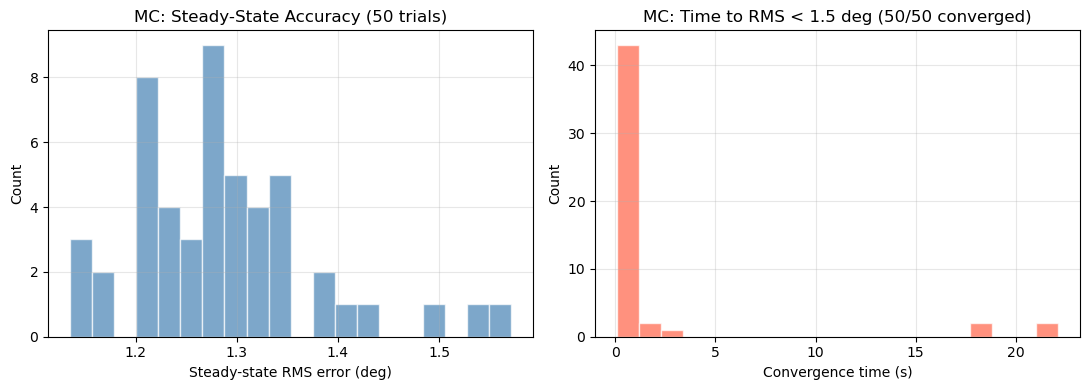

Monte Carlo plots generated.


In [48]:
fig8, (ax8a, ax8b) = subplots(1, 2, figsize=(11, 4))

ax8a.hist(ss_errors_mc; bins=20, color="steelblue", alpha=0.7, edgecolor="white")
ax8a.set_xlabel("Steady-state RMS error (deg)")
ax8a.set_ylabel("Count")
ax8a.set_title("MC: Steady-State Accuracy ($N_mc trials)")
ax8a.grid(true, alpha=0.3)

valid_conv = .!isnan.(conv_times_mc)
if any(valid_conv)
    ax8b.hist(conv_times_mc[valid_conv]; bins=20, color="tomato", alpha=0.7, edgecolor="white")
else
    ax8b.text(0.5, 0.5, "No converged trials", ha="center", va="center", transform=ax8b.transAxes)
end
ax8b.set_xlabel("Convergence time (s)")
ax8b.set_ylabel("Count")
ax8b.set_title("MC: Time to RMS < 1.5 deg ($(count(valid_conv))/$N_mc converged)")
ax8b.grid(true, alpha=0.3)

tight_layout()
display(fig8)
println("Monte Carlo plots generated.")